# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Jesse van der Meulen
* Username: jrhmeulen
* Student number: S6445128
* Group (AS1, etc.): AS1

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

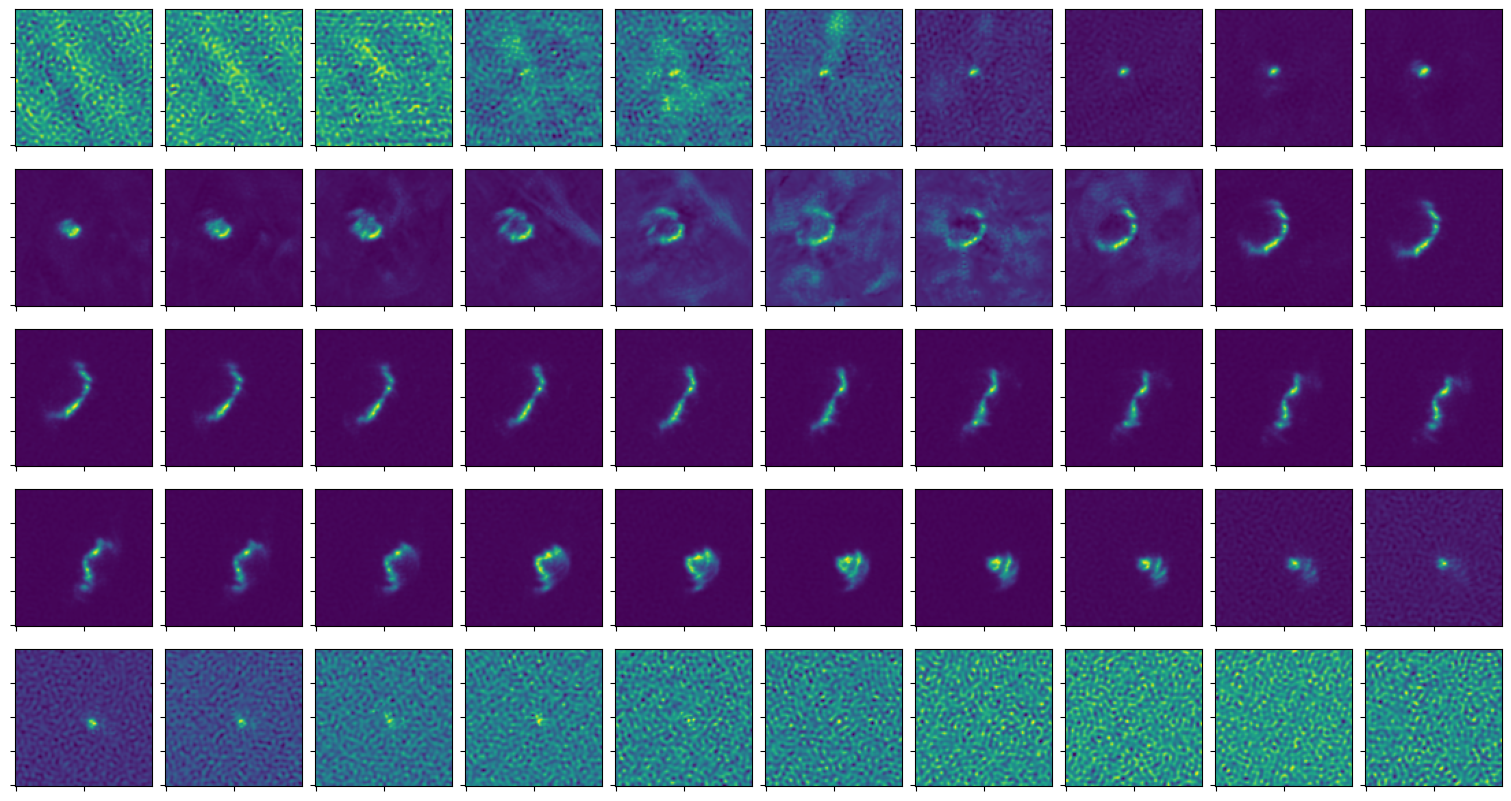

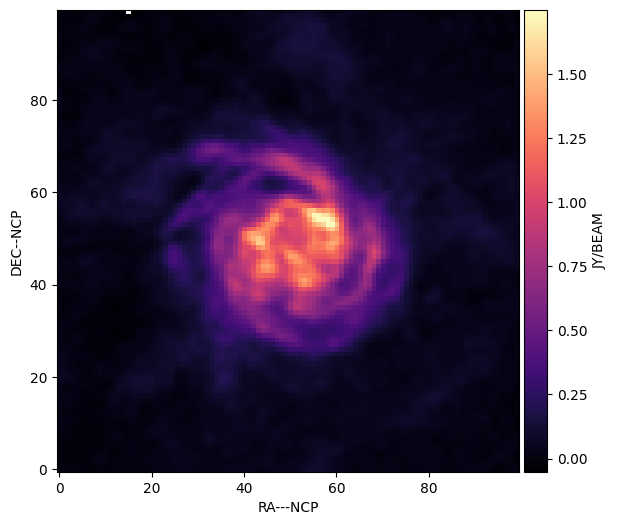

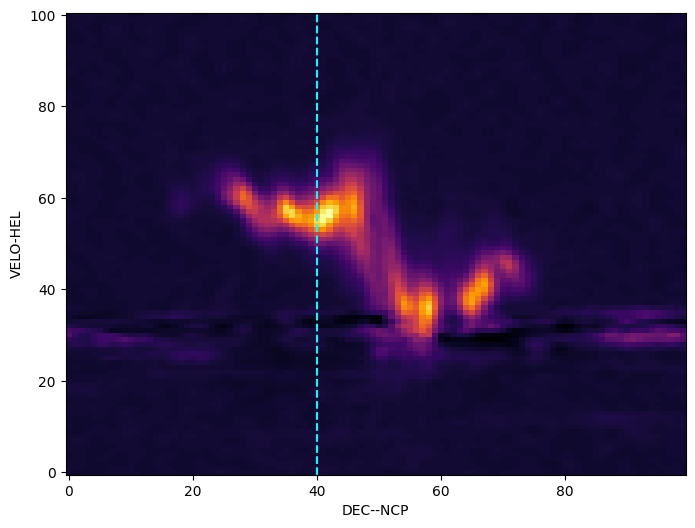

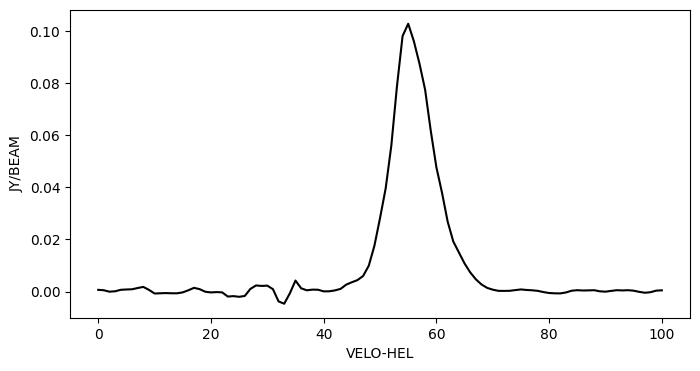

This profile is simply the plot of the values located along the vertical line


In [6]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

#1
with fits.open('ngc6946.fits') as hdul:
    data = np.squeeze(hdul[0].data)
    header = hdul[0].header
ctype1 = header.get('CTYPE1', 'RA')
ctype2 = header.get('CTYPE2', 'Dec')
ctype3 = header.get('CTYPE3', 'Velocity')
bunit = header.get('BUNIT', 'Intensity')

#2 3
indices = range(1, 101, 2)
fig2, axes2 = plt.subplots(5, 10, figsize=(15, 8), constrained_layout=True)
axes_flat = axes2.flatten()
for i, idx in enumerate(indices):
    ax = axes_flat[i]
    ax.imshow(data[idx, :, :], origin='lower', cmap='viridis')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
plt.show()

#4
hi_map = np.sum(data[20:80, :, :], axis=0)
fig4, ax4 = plt.subplots(figsize=(8, 6))
im4 = ax4.imshow(hi_map, origin='lower', cmap='magma')
ax4.set_xlabel(ctype1)
ax4.set_ylabel(ctype2)
divider4 = make_axes_locatable(ax4)
cax4 = divider4.append_axes("right", size="5%", pad=0.05)
cbar4 = plt.colorbar(im4, cax=cax4)
cbar4.set_label(bunit)
plt.show()

#5
pv_map = data[:, :, 50] 
fig5, ax5 = plt.subplots(figsize=(8, 6))
ax5.imshow(pv_map, origin='lower', aspect='auto', cmap='inferno')
ax5.axvline(x=40, color='cyan', linestyle='--')
ax5.set_xlabel(ctype2)
ax5.set_ylabel(ctype3)
plt.show()

#6
spectrum = data[:, 40, 50]
fig6, ax6 = plt.subplots(figsize=(8, 4))
ax6.plot(spectrum, color='black')
ax6.set_xlabel(ctype3)
ax6.set_ylabel(bunit)
plt.show()

#7
print('This profile is simply the plot of the values located along the vertical line')

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

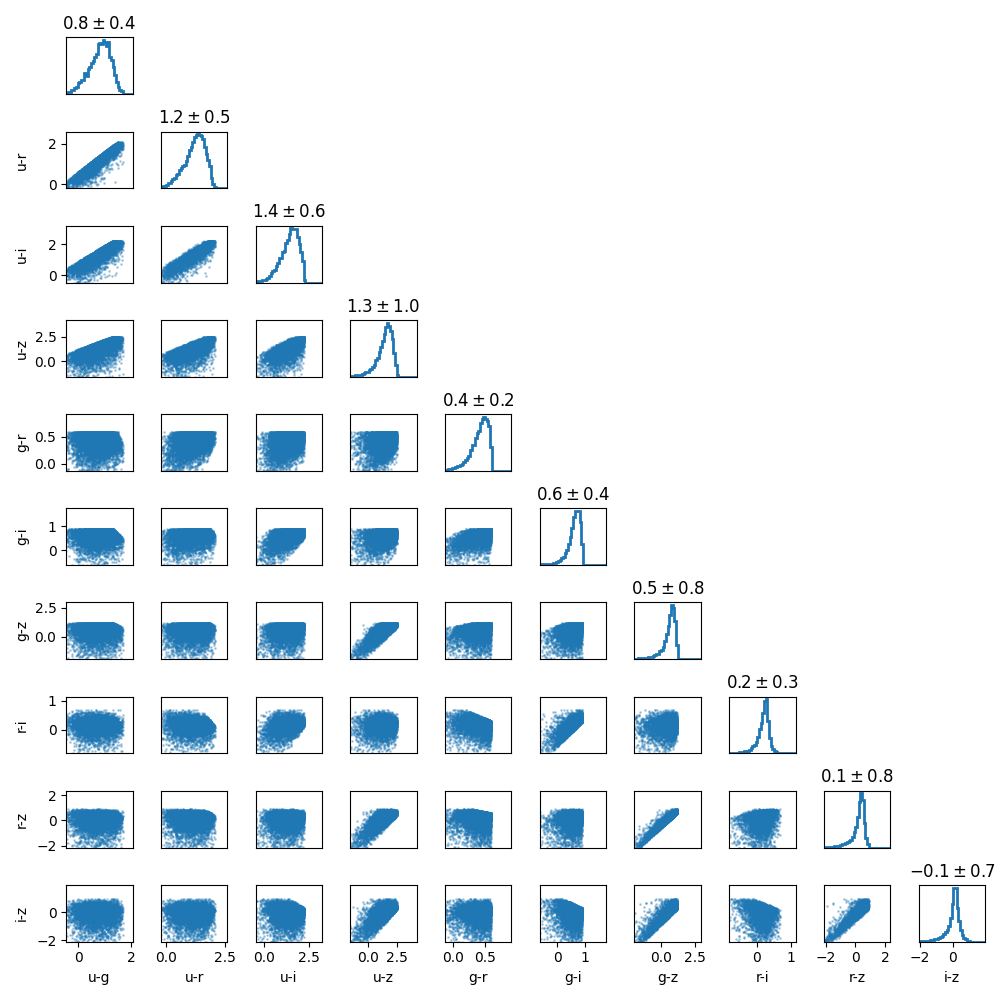
   
**Plot and answer**:

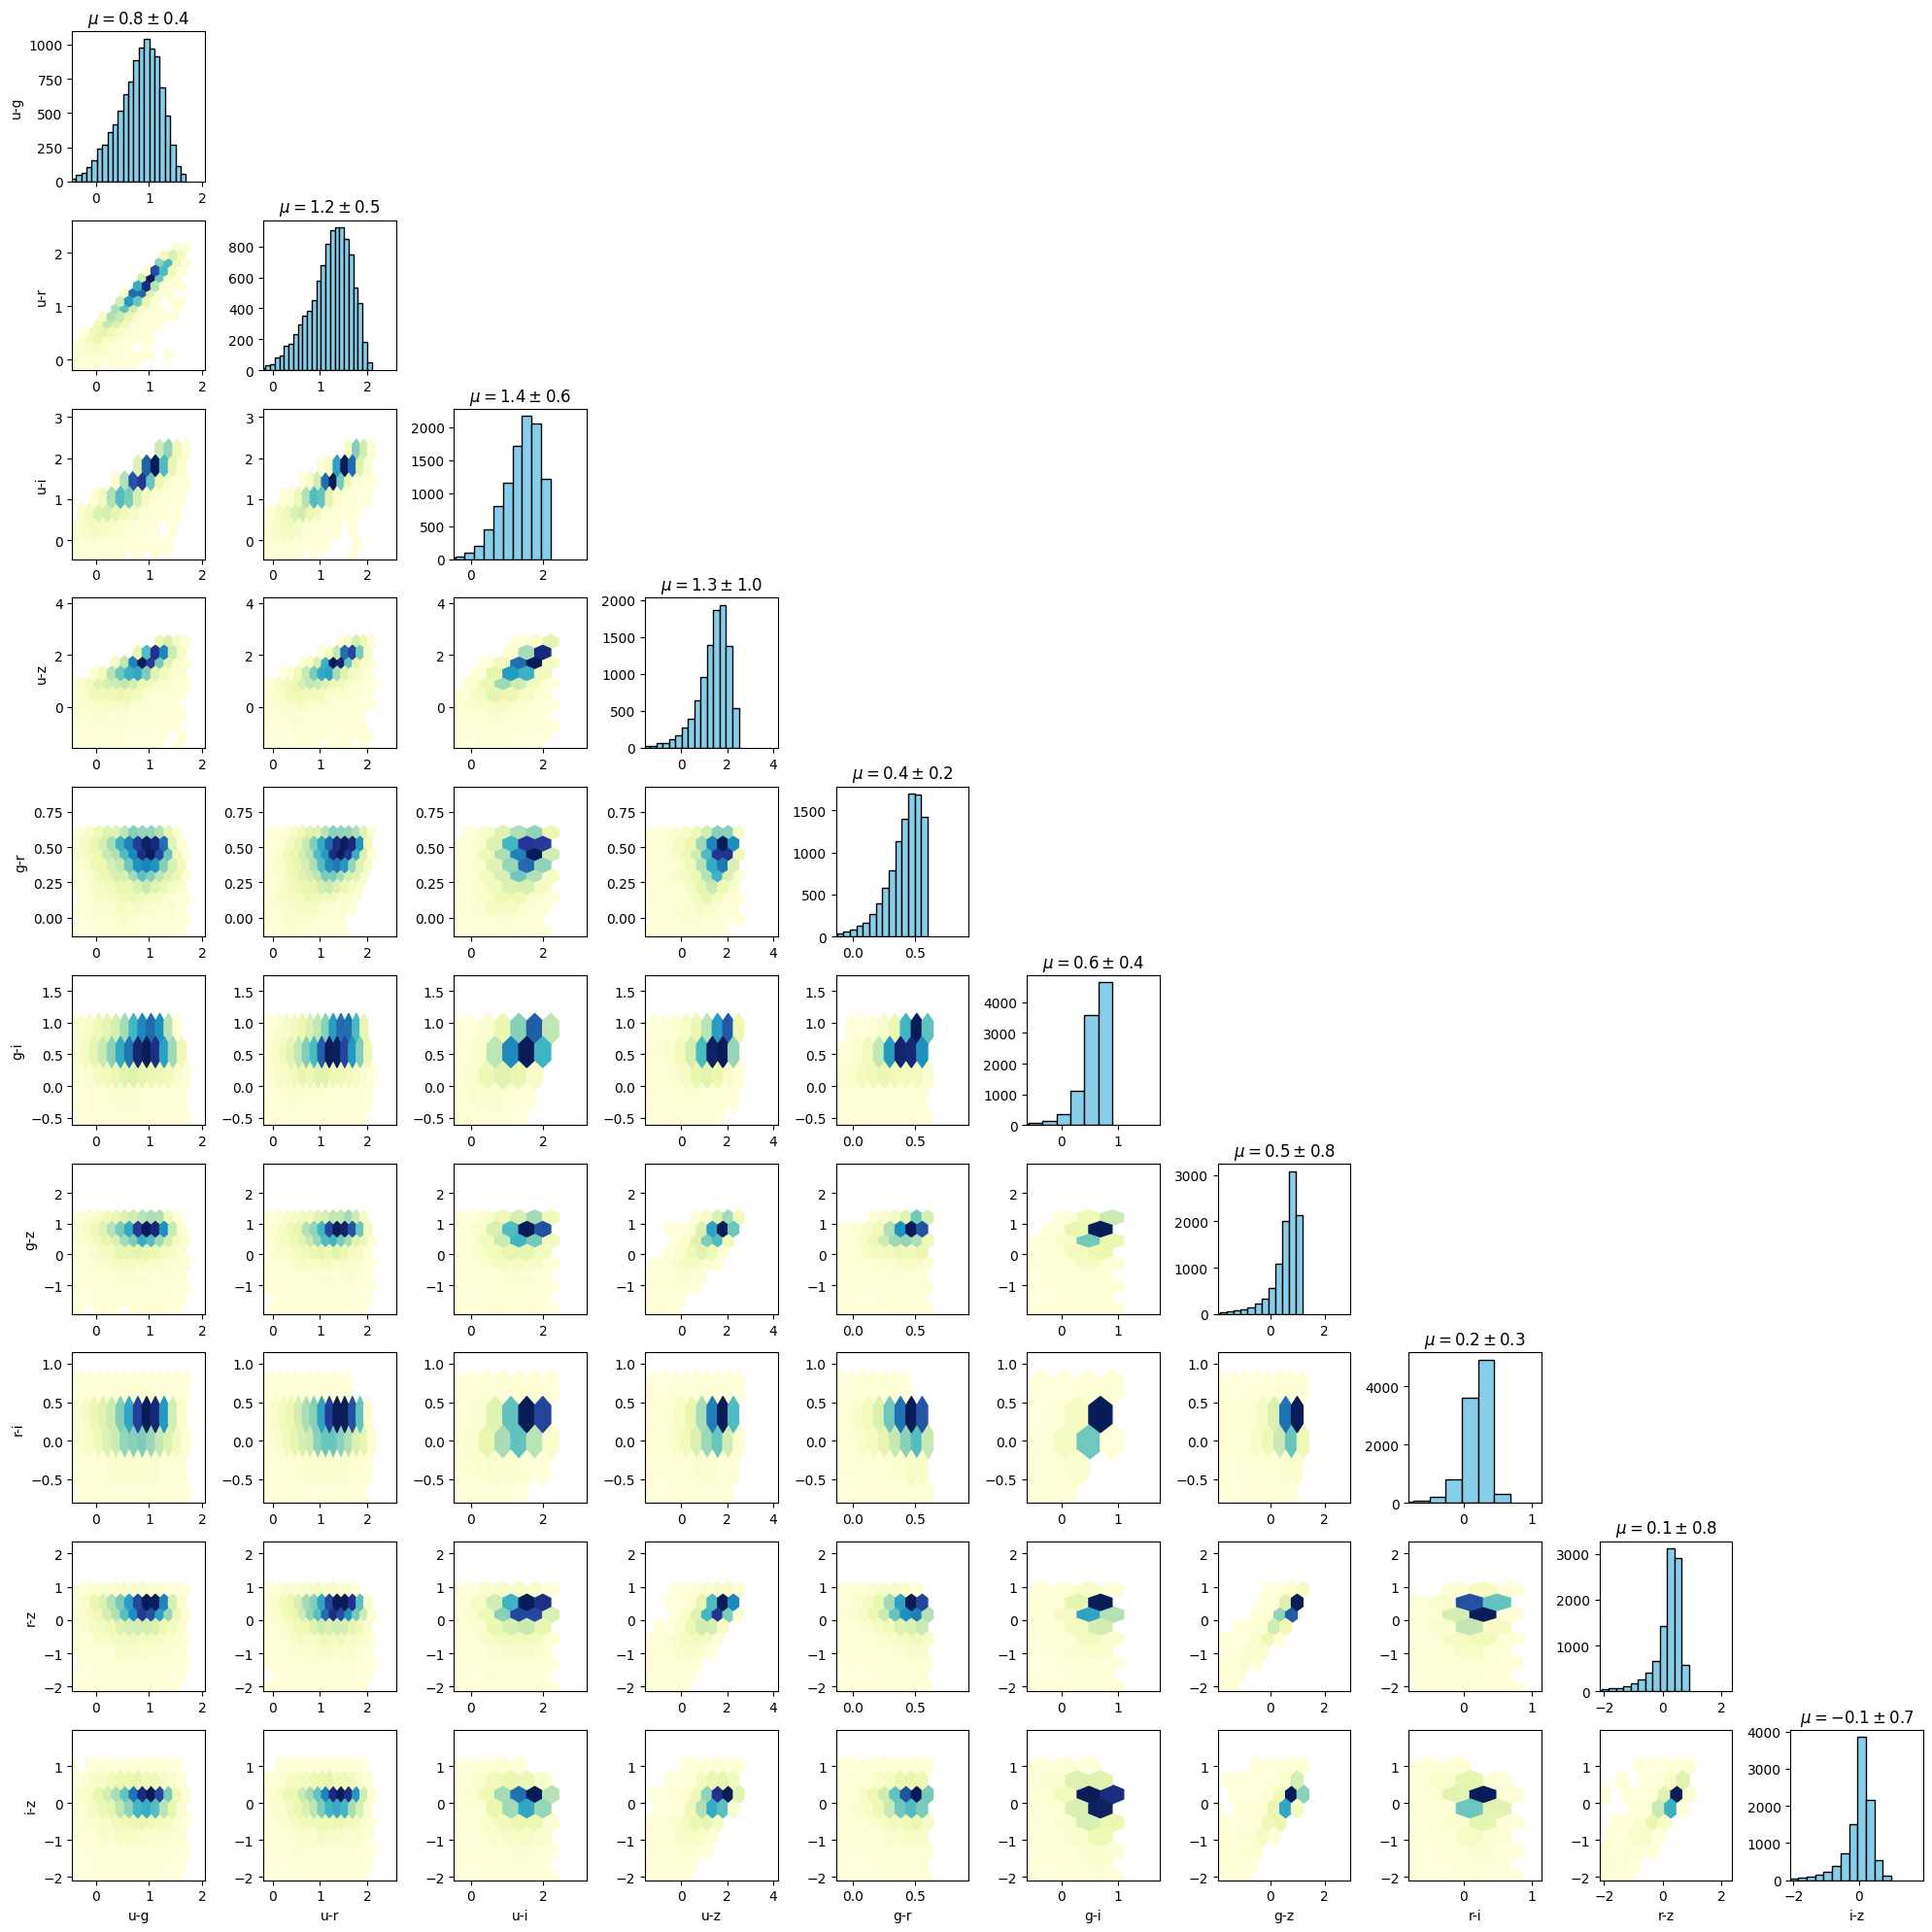

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from itertools import combinations

dat = Table.read('SDSS_DR17_galaxies.fits')
df = dat.to_pandas()

filters = ['u', 'g', 'r', 'i', 'z']
df = df[(df[filters] > 0).all(axis=1)]

color_cols = []
for f1, f2 in combinations(filters, 2):
    name = f'{f1}-{f2}'
    df[name] = df[f1] - df[f2]
    color_cols.append(name)
    
stats = df[color_cols].agg(['mean', 'std']).T
n = len(color_cols)

fig, axes = plt.subplots(n, n, figsize=(20, 20))

for i, row_name in enumerate(color_cols):
    row_mu = stats.loc[row_name, 'mean']
    row_std = stats.loc[row_name, 'std']
    for j, col_name in enumerate(color_cols):
        ax = axes[i, j]
        col_mu = stats.loc[col_name, 'mean']
        col_std = stats.loc[col_name, 'std']
        
        if i == j:
            ax.hist(df[row_name], bins=50, color='skyblue', edgecolor='black')
            ax.set_title(fr'$\mu={row_mu:.1f} \pm {row_std:.1f}$')

        elif i > j:
            ax.hexbin(df[col_name], df[row_name], gridsize=30, cmap='YlGnBu', mincnt=1)
        else:
            ax.axis('off')
            continue
        ax.set_xlim(col_mu - 3 * col_std, col_mu + 3 * col_std)
        if i != j:
            ax.set_ylim(row_mu - 3 * row_std, row_mu + 3 * row_std)
        if i == n - 1: ax.set_xlabel(col_name)
        if j == 0: ax.set_ylabel(row_name)
plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

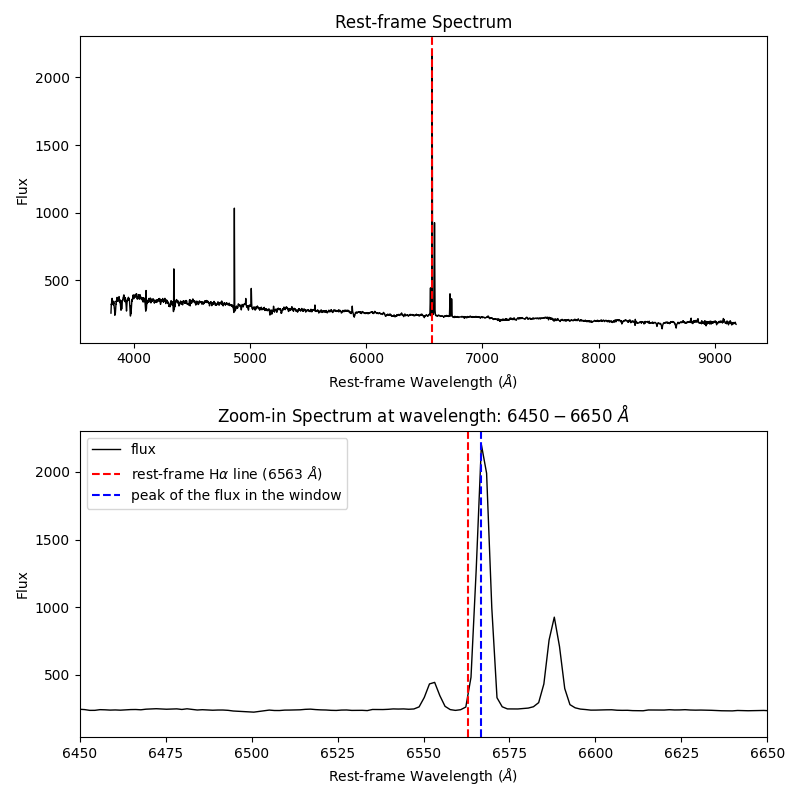

/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.11.909) or chardet (4.0.0)/charset_normalizer (2.0.4) doesn't match a supported version!
  warnings.warn(


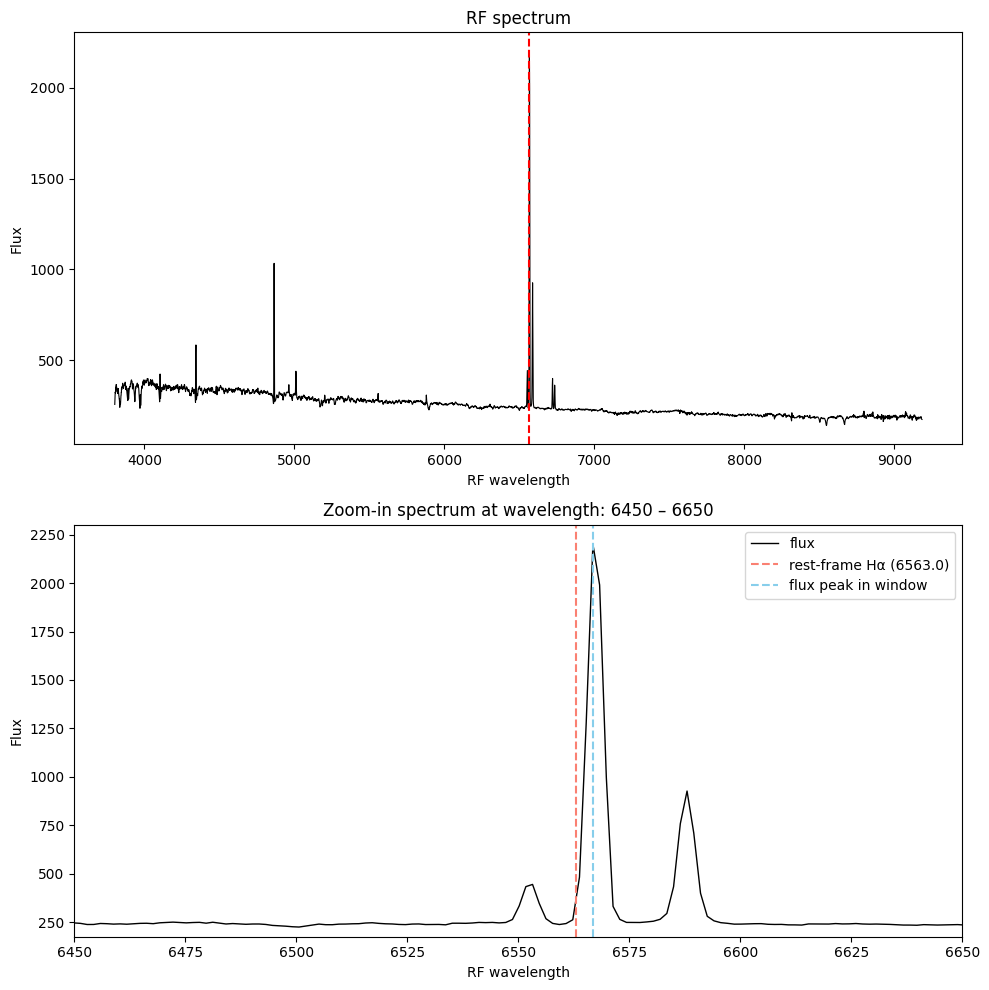

Velocity offset: 172.88 km/s


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import coordinates as coords
from astropy import units as u
from astroquery.sdss import SDSS

ra, dec = 40.6696, -0.0133
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
z = 0.0038
ha_rest = 6563.0

spectra = SDSS.get_spectra(coordinates=pos, radius=10*u.arcsec)
hdul = spectra[0]
data = hdul[1].data

flux = data['flux']
loglam = data['loglam']
wavelength_obs = 10**loglam
wavelength_rest = wavelength_obs / (1 + z)

mask = (wavelength_rest >= 6450) & (wavelength_rest <= 6650)
zoom_wave = wavelength_rest[mask]
zoom_flux = flux[mask]
peak_wave = zoom_wave[np.argmax(zoom_flux)]

c = 299792.458 
v_offset = c * (peak_wave - ha_rest) / ha_rest

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.plot(wavelength_rest, flux, color='black', lw=0.8)
ax1.axvline(ha_rest, color='red', linestyle='--')
ax1.set_title('RF spectrum')
ax1.set_xlabel('RF wavelength')
ax1.set_ylabel('Flux')

ax2.plot(wavelength_rest, flux, color='black', lw=1, label='flux')
ax2.axvline(ha_rest, color='salmon', linestyle='--', label=f'rest-frame Hα ({ha_rest})')
ax2.axvline(peak_wave, color='skyblue', linestyle='--', label='flux peak in window')
ax2.set_xlim(6450, 6650)
ax2.set_ylim(min(zoom_flux) - 50, max(zoom_flux) + 100)
ax2.set_title('Zoom-in spectrum at wavelength: 6450 – 6650')
ax2.set_xlabel('RF wavelength')
ax2.set_ylabel('Flux')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Velocity offset: {v_offset:.2f} km/s")

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

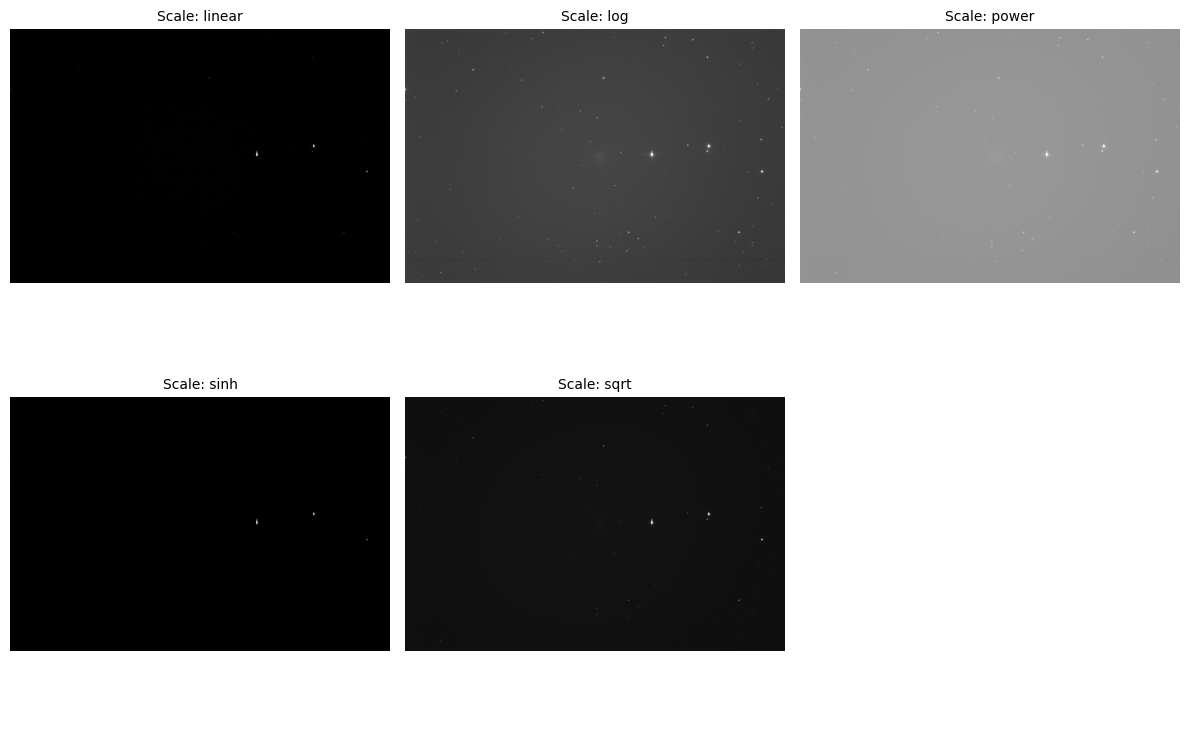

In [3]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from astropy.visualization import (MinMaxInterval, LogStretch, PowerStretch, SinhStretch, SqrtStretch, ImageNormalize)

def imdisplay(data, scale='linear', ax=None):
    """
    Displays an astronomical image with a specified stretch/scale.
    Parameters:
    data : array-like
     The 2D image data (from a FITS file).
    scale : str
     The scaling method to use. Options: 'linear', 'log', 'power', 'sinh', 'sqrt'.
    ax : matplotlib.axes.Axes, optional
     The axes object to plot on. If None, creates a new figure.
    """
    if scale == 'linear':
        s = None
    elif scale == 'log':
        s = LogStretch()
    elif scale == 'power':
        s = PowerStretch(a=0.1)
    elif scale == 'sinh':
        s = SinhStretch()
    elif scale == 'sqrt':
        s = SqrtStretch()
    else:
        s = None

    inter = MinMaxInterval()
    if s is not None:
        n = ImageNormalize(data, interval=inter, stretch=s)
    else:
        n = ImageNormalize(data, interval=inter)

    if ax is None:
        f, ax = plt.subplots()

    ax.imshow(data, cmap='gray', norm=n, origin='lower')
    ax.set_title("Scale: " + str(scale), fontsize=10)
    ax.axis('off')

file = '20210422_Li_.00000066.FIT'
hdulist = fits.open(file)
img = hdulist[0].data
hdulist.close()

all_scales = ['linear', 'log', 'power', 'sinh', 'sqrt']
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
axs = axs.flatten()

for i in range(len(all_scales)):
    sc = all_scales[i]
    imdisplay(img, scale=sc, ax=axs[i])
axs[5].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

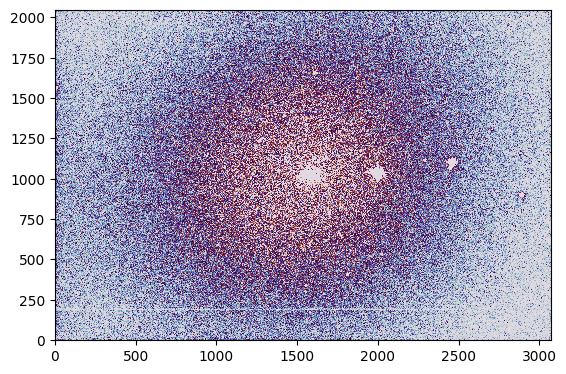

(2048, 3072)


In [12]:
import numpy as np
from pathlib import Path
from astropy.io import fits
from astropy.visualization import * 
from matplotlib.pyplot import *
from math import *

datadir = "/Users/users/jrhmeulen/PROGNUM-repo/Task6" 
p = Path(datadir)
bad = ['BIAS', 'FLAT', 'DARK']

def imdisplay(data, ax, vmin=None, vmax=None, percentlow=1, percenthigh=99, zscale=False, scale='linear', power=1.5, cmap='gray', **kwargs):
    if zscale:
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None: vmin = vmin2
        if vmax is None: vmax = vmax2
            
    if scale == 'linear': stretch = LinearStretch(0.5, 0.5)
    elif scale == 'sinh': stretch = SinhStretch()
    elif scale == 'log': stretch = LogStretch()
    elif scale == 'power': stretch = PowerStretch(power)
    elif scale == 'sqrt': stretch = SqrtStretch()
    elif scale == 'squared': stretch = SquaredStretch()
    elif scale == 'hist':
        stretch = HistEqStretch(data)
        vmin = data.min(); vmax = data.max()
    n = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=n, cmap=cmap, **kwargs)

files = []
for x in p.iterdir():
    if x.suffix.lower() in ['.fits', '.fit'] and '_Li_' in x.name:
        if not any(b in x.name for b in bad):
            files.append(x)
imgs = []
for f in files:
    with fits.open(f) as hdul:
        if hdul[0].is_image:
            d = hdul[0].data.astype('float64')
            imgs.append(d)
        else:
            print(f"Skipping {f.name} - it's a table!")

cube = np.stack(imgs)
result = np.median(cube, axis=0)

fig, ax = subplots()
imdisplay(result, ax, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
show()

print(result.shape)

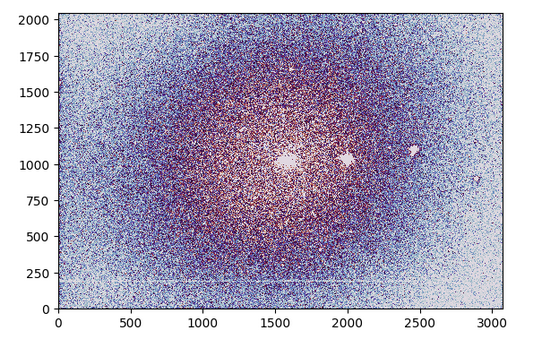

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")